In [63]:
import numpy as np
import cupy as cp
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

shape    = (400, 350)    # Nombre de píxels (Ny, Nz) a la pantalla.
y_range  = (-20, 20)     # Rang en el pla equatorial del forat negre.
z_range  = (-10, 15)     # Rang en la direcció de l'eix de rotació.
M        = 1             # Massa del forat negre.
camera_angle = 0.05

# Definim alguns radis significatius
r_horizon = 2 * M
r_shadow  = 3 * np.sqrt(3) * M 
r_ISCO    = 6 * M
r_disk    = 18

# Angle de 0 a 2pi, que serà útil per dibuixar cercles.
contour  = np.linspace(0, 2 * np.pi, 100)

In [64]:
# Definim les coordenades (t, x, y, z) inicials de l'eixam. 
t_screen = 0.0
u_screen = 50.0
y_screen = cp.linspace(*y_range, shape[0])[:, None]
v_screen = cp.linspace(*z_range, shape[1])[None, :]

x_screen = cp.cos(camera_angle) * u_screen - cp.sin(camera_angle) * v_screen
z_screen = cp.cos(camera_angle) * v_screen + cp.sin(camera_angle) * u_screen

# Passem a coordenades esfèriques, per la mètrica de Schwarzschild.
t  = t_screen
r  = cp.sqrt(x_screen**2 + y_screen**2 + z_screen**2)
th = cp.arccos(z_screen / r)
ph = cp.arctan2(y_screen, x_screen)

# Posem primer les components espacials de la 4-velocitat, alineada amb l'eix x.
# Aquestes expressions són les components de - d/dx en coordenades esfèriques.

ddx = ( cp.sin(th) * cp.cos(ph), cp.cos(th) * cp.cos(ph) / r, - cp.sin(ph) / (r * cp.sin(th) + 1e-5 * (cp.sin(th) == 0) ))
ddz = ( cp.cos(th), - cp.sin(th) / r, 0*r)

dr_dl  = - cp.cos(camera_angle) * ddx[0] - cp.sin(camera_angle) * ddz[0]
dth_dl = - cp.cos(camera_angle) * ddx[1] - cp.sin(camera_angle) * ddz[1]
dph_dl = - cp.cos(camera_angle) * ddx[2] - cp.sin(camera_angle) * ddz[2]

# Ara normalitzem per tal que dt / dlambda = 1 i la 4-velocitat sigui nul·la.
norm2  = dr_dl**2 / (1 - 2 * M / r) + r**2 * (dth_dl**2 + cp.sin(th)**2 * dph_dl**2)
factor = cp.sqrt(norm2 / (1 - 2*M / r))

# Definim un eixam de fotons sobre la pantalla, amb els que farem el ray tracing.
swarm_init = cp.zeros(shape + (8,))

swarm_init[..., 0] = t
swarm_init[..., 1] = r
swarm_init[..., 2] = th
swarm_init[..., 3] = ph

swarm_init[..., 4] = 1
swarm_init[..., 5] = dr_dl  / factor
swarm_init[..., 6] = dth_dl / factor
swarm_init[..., 7] = dph_dl / factor

# Comprovem que la 4-velocitat és efectivament nul·la
cp.allclose(- (1 - 2 * M / r) * swarm_init[..., 4]**2 + swarm_init[..., 5]**2 / (1 - 2 * M / r) + \
            r**2 * (swarm_init[..., 6]**2 + cp.sin(th)**2 * swarm_init[..., 7]**2), 0)

array(True)

In [65]:
# Càlcul dels símbols de Christoffel, que es retornen amb la forma (Ny, Nz).
# Important: cal tenir en compte que són simètrics en els dos índexs de baix.

def christoffel(swarm, indices):
    # No necessitem la 4-velocitat per als Christoffels, la podem llençar
    _, r, th, ph, _, _, _, _  = swarm.transpose(2, 0, 1)

    if indices == (1, 0, 0):  # Γ^r_tt
        gamma = M * (r - 2 * M) / r**3

    elif (indices == (0, 0, 1)) or (indices == (0, 1, 0)):  # Γ^t_tr
        gamma = M / (r * (r - 2 * M))

    elif indices == (1, 1, 1):  # Γ^r_rr
        gamma = -M / (r * (r - 2 * M))

    elif indices == (1, 2, 2):  # Γ^r_θθ
        gamma = -(r - 2 * M)

    elif indices == (1, 3, 3):  # Γ^r_φφ
        gamma = -(r - 2 * M) * cp.sin(th)**2

    elif (indices == (2, 1, 2)) or (indices == (2, 2, 1)):  # Γ^θ_rθ
        gamma = 1 / r

    elif indices == (2, 3, 3):  # Γ^θ_φφ
        gamma = -cp.sin(th) * cp.cos(th)

    elif (indices == (3, 1, 3)) or (indices == (3, 3, 1)):  # Γ^φ_rφ
        gamma = 1 / r

    elif (indices == (3, 2, 3)) or (indices == (3, 3, 2)):  # Γ^φ_θφ
        gamma = cp.cos(th) / (cp.sin(th) + 1e-5 * (cp.sin(th) == 0))

    else:
        gamma = None

    return gamma


In [66]:
# Funció que calculi la derivada de l'array swarm respecte 
# al paràmetre afí a partir de l'equació geodèsica.

def geoeq(swarm):
    
    dswarm = cp.zeros_like(swarm) 
    dswarm[..., :4] = swarm[..., 4:]
    
    for idx1 in range(4):
        for idx2 in range(4):
            for idx3 in range(idx2, 4):
                gamma = christoffel(swarm, (idx1, idx2, idx3))
                if gamma is not None:
                    # Sumem dues vegades els termes amb índexs diferents, per la simetria dels símbols de Christoffel.
                    dswarm[..., idx1 + 4] -= (2 - (idx2 == idx3)) * gamma * swarm[..., idx2 + 4] * swarm[..., idx3 + 4]

    dswarm[stopped_mask, :] = 0.0
    return dswarm

# Funció que comprova la posició de cada fotó i actualitza
# les màscares que es faran servir en l'evolució.

def update_masks(swarm, new_swarm):

    _, r, th, _, _, _, _, _    = swarm.transpose(2, 0, 1)
    _, _, n_th, _, _, _, _, _  = new_swarm.transpose(2, 0, 1)
    
    fell_into_horizon     = (r <= 1.1 * r_horizon)
    went_too_far          = (r > 60)
    crossed_the_equator   = (cp.cos(th) * cp.cos(n_th) < 0)
    hit_the_disk          = crossed_the_equator & (r > r_ISCO) & (r < r_disk)
    canvas[hit_the_disk] += r[hit_the_disk]
    
    stopped_mask[fell_into_horizon | went_too_far] = True
    
# Integrador Runge-Kutta 4 que aprofita la funció anterior per 
# evolucionar l'array swarm un pas de paràmetre afí dlam.

def RK4(lam, swarm):
    k1 = geoeq(swarm)
    k2 = geoeq(swarm + 0.5 * k1 * dlam)
    k3 = geoeq(swarm + 0.5 * k2 * dlam)
    k4 = geoeq(swarm + k3 * dlam)

    new_lam   = lam + dlam
    new_swarm = swarm + dlam * (k1 + 2*k2 + 2*k3 + k4) / 6

    update_masks(swarm, new_swarm)
    
    return new_lam, new_swarm


In [67]:
# Posem el paràmetre afí lam = 0 per a tots els fotons.
lam, dlam = 0, 0.1

# Inicialitzem l'eixam de fotons i els arrays on guardar-lo.
swarm = swarm_init

# Inicialitzem les màscares
stopped_mask      = cp.zeros_like(r, dtype = bool)
canvas            = cp.zeros_like(r)

for it in tqdm(range(2500)):  
    lam, swarm = RK4(lam, swarm)

print(f'Paràmetre afí al final de la integració: {lam:.2f}')


  0%|          | 0/2500 [00:00<?, ?it/s]

Paràmetre afí al final de la integració: 250.00


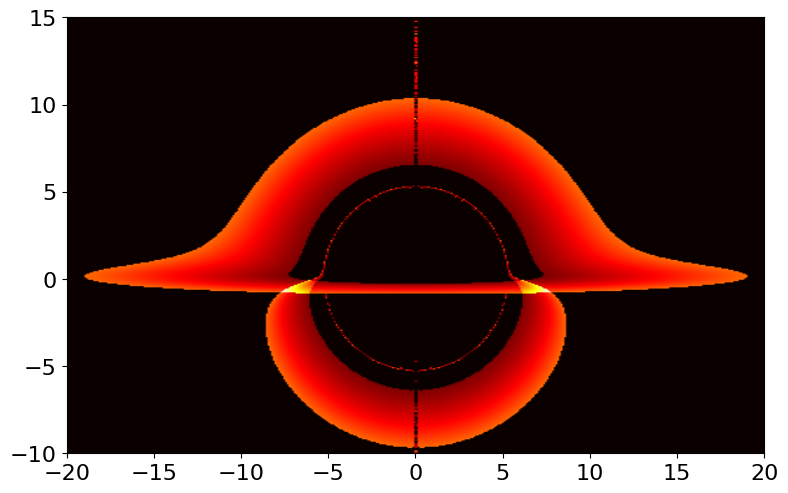

In [68]:
fig, ax = plt.subplots(1, 1, figsize = (9, 6));
plt.rc('font', size = 16)

ax.imshow(cp.asnumpy(canvas).T, cmap = 'hot', origin = 'lower', interpolation = 'bilinear', extent = y_range + z_range)
plt.savefig('BlackHole.png', dpi = 1000, bbox_inches='tight', pad_inches = 0)

In [48]:
np.pi / 10

0.3141592653589793